In [4]:
# Install required packages
%pip install -q transformers datasets scikit-learn

### GPU Check

In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


### Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Upload Dataset

In [ ]:
import shutil

drive_csv_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/Dataset/nav_dataset_b4.3.csv"
shutil.copy(drive_csv_path, "nav_dataset.csv")
print("Dataset ready!")


### Load and Split Dataset

In [ ]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

df = pd.read_csv("nav_dataset.csv")

# Remove exact duplicates based on both input and target
before_rows = len(df)
df = df.drop_duplicates(subset=["input", "target"]).reset_index(drop=True)
after_rows = len(df)

print("Data cleanup summary")
print(f"Rows before cleanup: {before_rows}")
print(f"Duplicate rows removed: {before_rows - after_rows}")
print(f"Rows remaining: {after_rows}")

# Extract action type for stratification
df['action_type'] = df['input'].str.extract(r'action: (\w+)')

print("\nAction type distribution (full dataset):")
print(df['action_type'].value_counts().to_string())

# Stratified 80/10/10 split.
# stratify=action_type ensures every action type keeps its proportion across
# train / val / test — prevents a split from being over-represented in one action.
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['action_type']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['action_type']
)

print("\nAction type distribution per split:")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split['action_type'].value_counts()
    print(f"  {name} ({len(split)}): {counts.to_dict()}")

# Drop helper column before building HuggingFace datasets
train_df = train_df.drop(columns=['action_type']).reset_index(drop=True)
val_df   = val_df.drop(columns=['action_type']).reset_index(drop=True)
test_df  = test_df.drop(columns=['action_type']).reset_index(drop=True)

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

print(f"\nTraining examples:   {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples:       {len(test_dataset)}")


### Tokenize Data

In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("t5-small")

def preprocess(examples):
    model_inputs = tokenizer(
        ["navigate: " + x for x in examples["input"]],
        max_length=128,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples["target"],
        max_length=64,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess, batched=True, remove_columns=val_dataset.column_names)
tokenized_test = test_dataset.map(preprocess, batched=True, remove_columns=test_dataset.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2032 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

Map:   0%|          | 0/254 [00:00<?, ? examples/s]

### Model Loading and Configuration

In [10]:
from transformers import (
    T5ForConditionalGeneration,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    )

model_output_dir = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
base_model_name = "t5-small"

training_config = {
    "output_dir": "./nav_t5_model_v1",
    "num_train_epochs": 15,
    "per_device_train_batch_size": 32,
    "per_device_eval_batch_size": 32,
    "warmup_steps": 100,
    "weight_decay": 0.01,
    "logging_dir": "./logs",
    "logging_steps": 10,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "fp16": True,
    "remove_unused_columns": False,
    "report_to": "none",
    "lr_scheduler_type": "cosine",
    "learning_rate": 3e-4,
    }

model = T5ForConditionalGeneration.from_pretrained(base_model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
training_args = TrainingArguments(**training_config)

run_artifacts = {
    "model_configuration": {
        "base_model": base_model_name,
        "tokenizer": base_model_name,
        "training_arguments": training_config,
        "early_stopping": {"patience": 3},
        "dataset_sizes": {
            "train": len(tokenized_train),
            "validation": len(tokenized_val),
            "test": len(tokenized_test),
            },
        },
    "epoch_losses": [],
    "training_summary": {},
    "curve_points": [],
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Train the model

In [11]:
import json
import os
import pandas as pd

train_result = trainer.train()
print(train_result.metrics)

log_df = pd.DataFrame(trainer.state.log_history)

train_epoch_df = (
    log_df.dropna(subset=["epoch", "loss"])
.groupby("epoch", as_index=False)["loss"]
    .last()
    .rename(columns={"loss": "training_loss"})
)

val_epoch_df = (
    log_df.dropna(subset=["epoch", "eval_loss"])
.groupby("epoch", as_index=False)["eval_loss"]
    .last()
    .rename(columns={"eval_loss": "validation_loss"})
)

epoch_results_df = train_epoch_df.merge(val_epoch_df, on="epoch", how="outer").sort_values("epoch")
epoch_results_df["epoch"] = epoch_results_df["epoch"].round().astype("Int64")

output_dir = model_output_dir if "model_output_dir" in globals() else "./nav_t5_model_v1"
os.makedirs(output_dir, exist_ok=True)
artifact_path = os.path.join(output_dir, "training_artifacts.json")

if "run_artifacts" not in globals():
    run_artifacts = {
        "model_configuration": {},
        "epoch_losses": [],
        "training_summary": {},
        "curve_points": [],
        }

run_artifacts["epoch_losses"] = epoch_results_df.where(pd.notnull(epoch_results_df), None).to_dict(orient="records")
run_artifacts["training_summary"] = train_result.metrics

with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(run_artifacts, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))

print(f"Saved artifacts to: {artifact_path}")

Epoch,Training Loss,Validation Loss
1,1.292525,0.945652
2,0.758716,0.619041
3,0.645489,0.556305
4,0.568985,0.526304
5,0.533728,0.506208
6,0.560352,0.507415
7,0.519291,0.491188
8,0.497102,0.488987
9,0.445540,0.485144
10,0.438965,0.474687


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


{'train_runtime': 184.2943, 'train_samples_per_second': 165.388, 'train_steps_per_second': 5.209, 'total_flos': 133057908572160.0, 'train_loss': 0.6995201248389024, 'epoch': 13.0}
Saved artifacts to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/training_artifacts.json


### Training Curves (Overfit / Underfit Check)
Plot training and validation loss from trainer logs to inspect model fit quality.

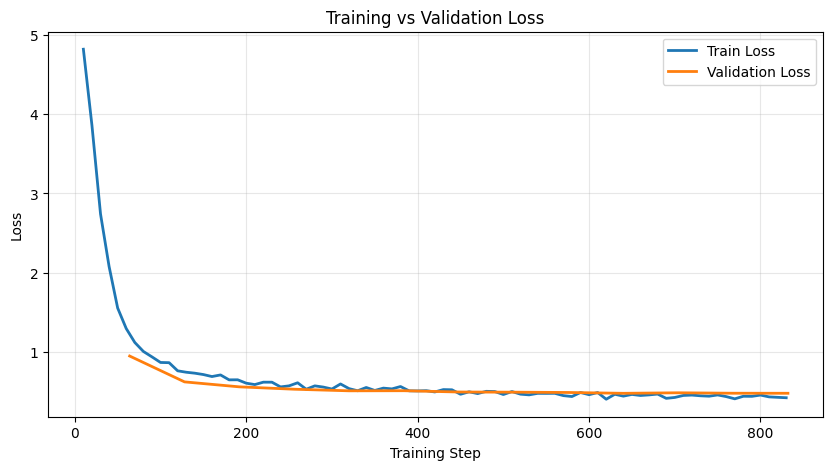

Latest train loss: 0.4186
Latest val loss:   0.4751
Generalization gap (val - train): 0.0565
Saved curve image to: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/training_validation_loss.png
Updated artifacts file: /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1/training_artifacts.json
Fit looks reasonable so far; confirm with held-out test metrics.


In [12]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.DataFrame(trainer.state.log_history)
train_loss_df = log_df.dropna(subset=["loss"])[["step", "epoch", "loss"]].copy()
eval_loss_df = log_df.dropna(subset=["eval_loss"])[["step", "epoch", "eval_loss"]].copy()

if train_loss_df.empty or eval_loss_df.empty:
    print("Not enough log data to plot train/eval losses.")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_df["step"], train_loss_df["loss"], label="Train Loss", linewidth=2)
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    output_dir = model_output_dir if "model_output_dir" in globals() else "./nav_t5_model_v1"
    os.makedirs(output_dir, exist_ok=True)

    curve_image_path = os.path.join(output_dir, "training_validation_loss.png")
    plt.savefig(curve_image_path, dpi=200, bbox_inches="tight")
    plt.show()

    train_curve_df = train_loss_df.rename(columns={"loss": "train_loss"})[["step", "train_loss"]]
    eval_curve_df = eval_loss_df.rename(columns={"eval_loss": "validation_loss"})[["step", "validation_loss"]]
    merged_curve_df = pd.merge(train_curve_df, eval_curve_df, on="step", how="outer").sort_values("step")

    artifact_path = os.path.join(output_dir, "training_artifacts.json")
    if "run_artifacts" not in globals():
        run_artifacts = {
            "model_configuration": {},
            "epoch_losses": [],
            "training_summary": {},
            "curve_points": [],
            }
    run_artifacts["curve_points"] = merged_curve_df.where(pd.notnull(merged_curve_df), None).to_dict(orient="records")

    with open(artifact_path, "w", encoding="utf-8") as f:
        json.dump(run_artifacts, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))

    latest_train_loss = float(train_loss_df.iloc[-1]["loss"])
    latest_val_loss = float(eval_loss_df.iloc[-1]["eval_loss"])
    loss_gap = latest_val_loss - latest_train_loss

    print(f"Latest train loss: {latest_train_loss:.4f}")
    print(f"Latest val loss:   {latest_val_loss:.4f}")
    print(f"Generalization gap (val - train): {loss_gap:.4f}")
    print(f"Saved curve image to: {curve_image_path}")
    print(f"Updated artifacts file: {artifact_path}")

    if loss_gap > 0.5:
        print("Potential overfitting signal: validation loss is much higher than training loss.")
    elif latest_train_loss > 1.5 and latest_val_loss > 1.5:
        print("Potential underfitting signal: both losses are still relatively high.")
    else:
        print("Fit looks reasonable so far; confirm with held-out test metrics.")

### Save Model

In [13]:
import os

save_path = model_output_dir if "model_output_dir" in globals() else "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")
print("Artifacts in same folder: training_artifacts.json and training_validation_loss.png")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1
Artifacts in same folder: training_artifacts.json and training_validation_loss.png


### Test Model

In [ ]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
import pandas as pd

model_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)
model = model.to(device)
model.eval()

def generate_from_text(input_text: str) -> str:
    full_input = "navigate: " + input_text
    inputs = tokenizer(full_input, return_tensors="pt", max_length=128, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model.generate(
        **inputs,
        max_length=64,
        min_new_tokens=4,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

# Evaluate against the held-out test set (10% of data, stratified by action type)
print(f"Evaluating on {len(test_df)} test examples...")

eval_results = []
for _, row in test_df.iterrows():
    predicted = generate_from_text(row['input'])
    exact_match = predicted.strip().lower() == row['target'].strip().lower()
    eval_results.append({
        'input':       row['input'],
        'target':      row['target'],
        'predicted':   predicted,
        'exact_match': exact_match,
    })

eval_results_df = pd.DataFrame(eval_results)
accuracy = eval_results_df['exact_match'].mean()

print(f"\nTest Set Accuracy (Exact Match): {accuracy:.1%}  "
      f"({int(eval_results_df['exact_match'].sum())}/{len(eval_results_df)})")
print("\n" + "=" * 70)
print("Sample predictions (first 20 examples):")
print("=" * 70)
for _, row in eval_results_df.head(20).iterrows():
    status = "OK  " if row['exact_match'] else "DIFF"
    print(f"[{status}] Input:     {row['input']}")
    print(f"       Target:    {row['target']}")
    print(f"       Predicted: {row['predicted']}")
    print("-" * 70)


### Test Set Accuracy Breakdown
Per-action-type accuracy on the stratified held-out test set, plus a full mismatch log for manual inspection.

In [ ]:
import pandas as pd

# Accuracy breakdown by action type
eval_results_df['action_type'] = eval_results_df['input'].str.extract(r'action: (\w+)')

by_action = (
    eval_results_df.groupby('action_type')['exact_match']
    .agg(correct='sum', total='count', accuracy='mean')
    .reset_index()
)
by_action['accuracy'] = by_action['accuracy'].map('{:.1%}'.format)

print("ACCURACY BY ACTION TYPE")
print("=" * 50)
print(by_action.to_string(index=False))
print(f"\nOverall: {eval_results_df['exact_match'].mean():.1%}  "
      f"({int(eval_results_df['exact_match'].sum())}/{len(eval_results_df)})")

# Full mismatch log — every wrong prediction is printed so it can be inspected
mismatches = eval_results_df[~eval_results_df['exact_match']]
print(f"\nMISMATCH LOG ({len(mismatches)} mismatches out of {len(eval_results_df)}):")
print("=" * 70)
for _, row in mismatches.iterrows():
    print(f"  Input:     {row['input']}")
    print(f"  Target:    {row['target']}")
    print(f"  Predicted: {row['predicted']}")
    print("-" * 70)
